# Análise de Atletas

- Gênero dos Atletas

In [1]:
import pandas as pd
import os
import shutil

import json
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
import seaborn as sns

## Abertura do dataset

In [2]:
caminho_arquivo = "../../bronze/olympics_athletes.parquet"

print(os.listdir("../../bronze"))

['olympics_athletes.json', 'olympics_athletes.parquet', 'olympics_medals.json', 'olympics_medals.parquet', 'olympics_sports.json', 'olympics_sports.parquet']


In [22]:
df_athletes = pd.read_parquet(caminho_arquivo, engine="pyarrow")

df_athletes.head()

,id,name,gender
0,2303707,A. Sansores,Male
1,2303703,Álvaro Ledón,Male
2,921722,Abelardo Cuevas,Male
3,2303702,V. Fernández,Male
4,2303738,A. F. Ruiz,Male


## Tabela e Visualização

In [26]:
df_total = df_athletes.drop_duplicates().reset_index()
df_total = df_athletes['gender'].value_counts().reset_index()

df_total

,gender,count
0,Male,121185
1,Female,45789


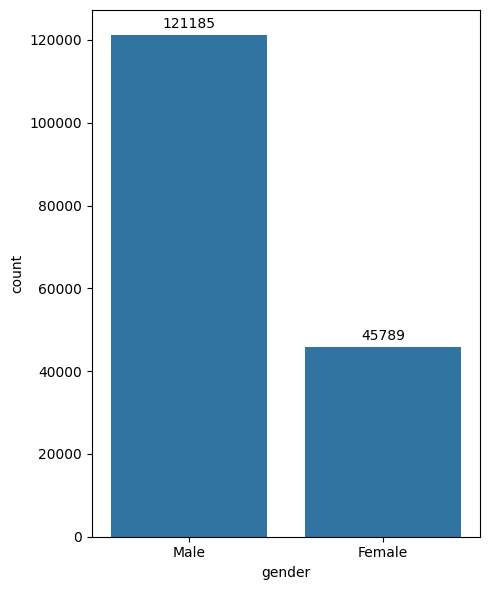

In [27]:
plt.figure(figsize=(5, 6))

ax = sns.barplot(data=df_total, 
                 x='gender',
                 y='count',
                 orient='v')

ax.bar_label((ax.containers[0]), color='black', padding=3)

plt.tight_layout()

plt.show()

## Salvando arquivo e metadados

In [28]:
# Salvando o dataset processado em CSV
df_total.reset_index().to_csv("athletes_gender_summary.csv", index=False)

In [ ]:
metadado = {
    "nome": "Total de Atletas Olímpicos por Gênero",
    "fonte": "olympic_athletes.parquet",
    "descricao": "Contagem de atletas homens e mulheres nas Olímpiadas",
    "campos": [
        "index",
        "gender",
        "count",
    ],
    "data_coleta": datetime.now().strftime("%d-%m-%Y"),
    "observacoes": "A contagem pode conter duplicatas por conta de não padronização dos nomes presentes nos datasets"
}

In [30]:
caminho_metadata = "athletes_gender_summary.json"

with open(caminho_metadata, "w", encoding='utf-8') as f:
    json.dump(metadado, f, ensure_ascii=False, indent=4)